In [10]:
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import numpy as np
import cmocean
from mpl_toolkits.basemap import Basemap

# -- Load data --
file_id = Dataset('../../data/chl/chl_1998_2025_l4_month_multi_4k.nc')
ras  = file_id.variables["CHL"][:]
lat  = file_id.variables["latitude"][:]
lon  = file_id.variables["longitude"][:]
time = file_id.variables["time"][:]
file_id.close()

# -- Build date vector --
timedelta_vector = (time * np.timedelta64(1, 'D')).astype('timedelta64[ns]')
base_date   = np.datetime64('1900-01-01')
date_vector = base_date + timedelta_vector

In [11]:
# Extract month from each date
months = date_vector.astype('datetime64[M]').astype(int) % 12 + 1

# Keep only June (6), July (7), September (9), October (10)
summer_mask = np.isin(months, [6, 7, 8, 9, 10])

dates_summer = date_vector[summer_mask]
ras_summer   = ras[summer_mask]
ras_summer   = np.clip(ras_summer, 0.05, 0.2)

# Build date labels
date_str_summer = np.datetime_as_string(dates_summer, unit='D')

# -- Coordinate grids --
lon_grid, lat_grid = np.meshgrid(lon, lat)

In [3]:
# -- Subset: adjust date range as needed --
# mask = (date_vector >= np.datetime64('2018-07-01')) & \
#       (date_vector <  np.datetime64('2018-11-01'))
# dates_sub = date_vector[mask]
# ras_sub   = ras[mask]
# ras_sub   = np.clip(ras_sub, 0.05, 0.25)

# Date labels
# date_str_vector = np.datetime_as_string(dates_sub, unit='D')

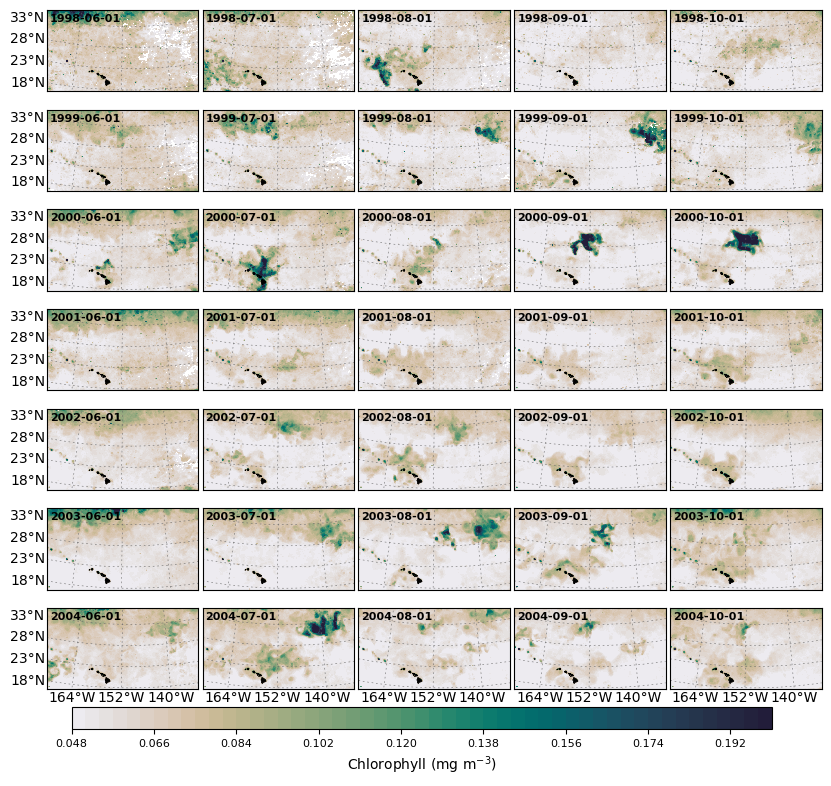

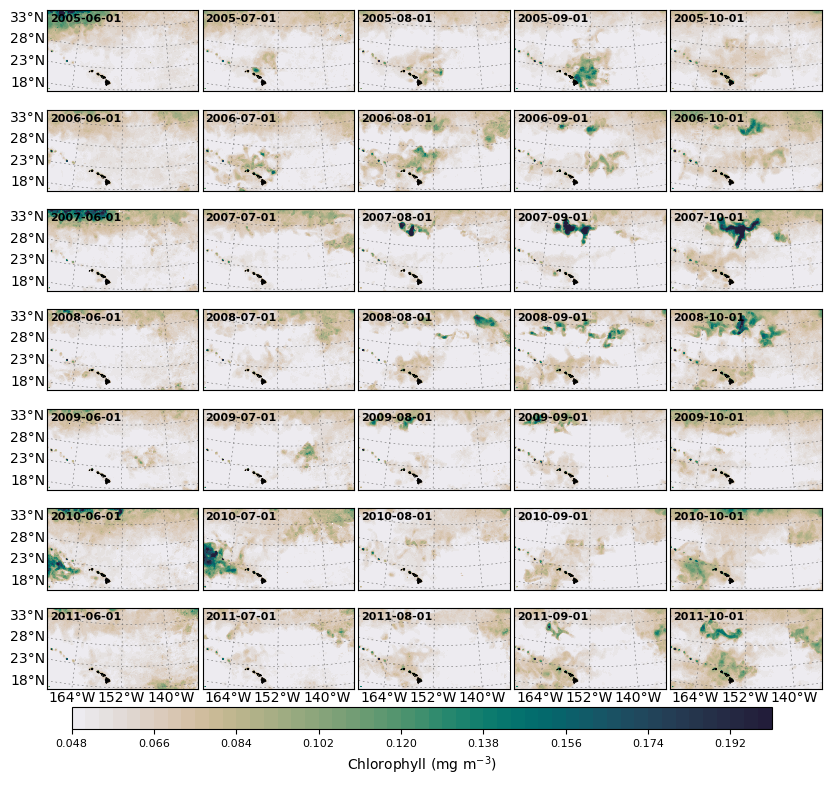

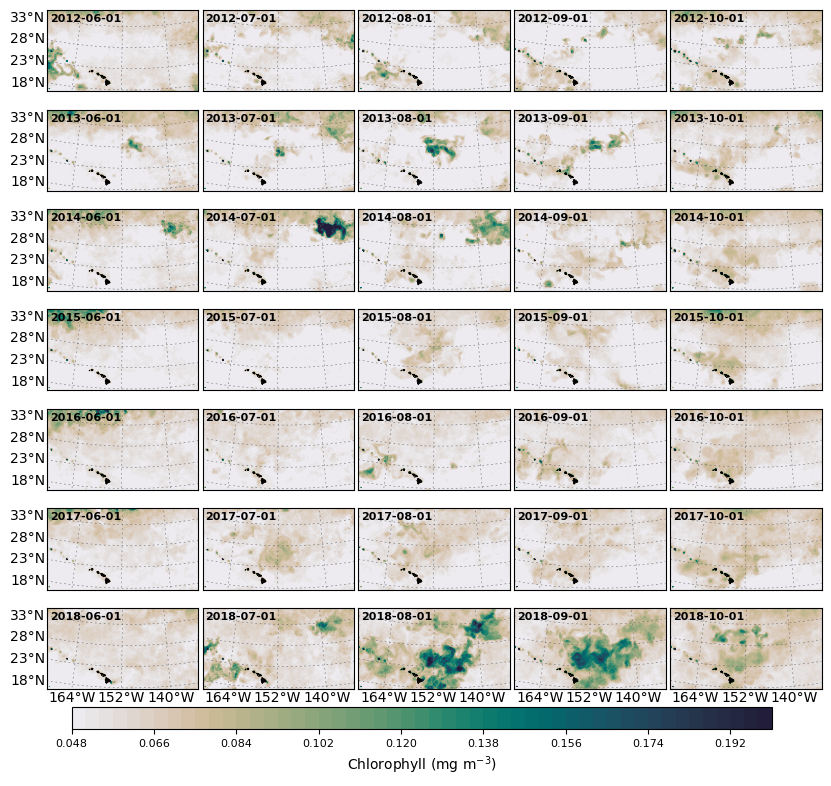

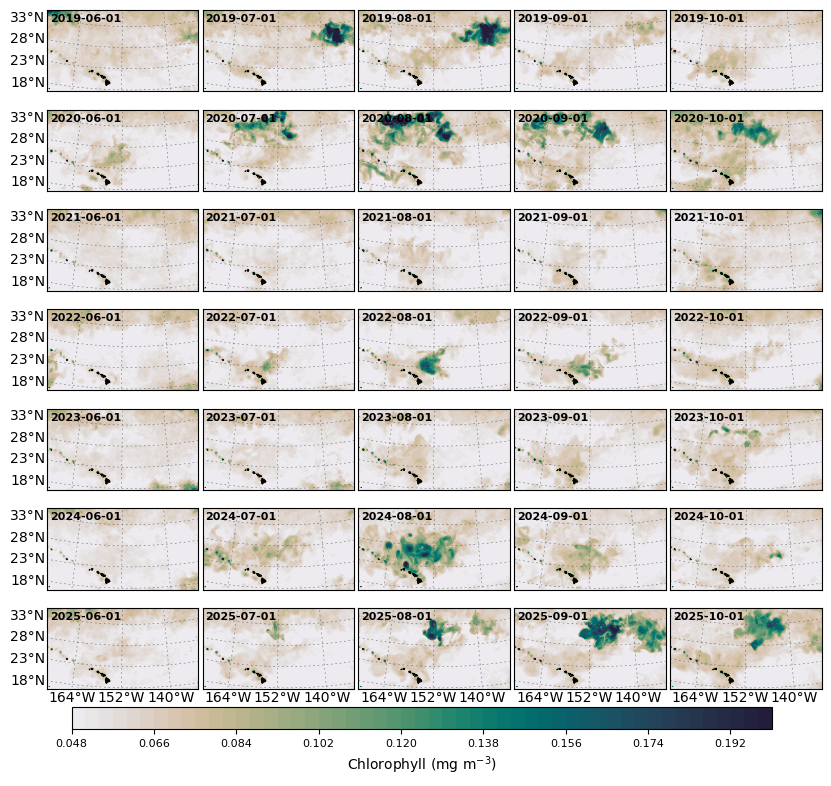

In [16]:
def plot_summer_chl(ras_data, date_labels, lon_grid, lat_grid, start=0, 
                    nrows=5, ncols=5, savename=None):
    """Plot a page of summer chlorophyll maps."""
    n_panels = nrows * ncols
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 11))

    for i, ax in enumerate(axs.flat):
        idx = start + i  # index into the full array

        m = Basemap(projection='lcc', resolution='h',
                    llcrnrlat=16, urcrnrlat=35.5,
                    llcrnrlon=-170, urcrnrlon=-130,
                    lat_0=30, lon_0=-150,
                    width=5.1E6, height=5E6,
                    ax=ax)

        x, y = m(lon_grid, lat_grid)

        cp = m.contourf(x, y, ras_data[idx, :, :],
                        levels=50, cmap=cmocean.cm.rain, extend='neither')

        ax.text(0.02, 0.95, date_labels[idx],
                transform=ax.transAxes,
                fontsize=8, fontweight='bold', va='top', ha='left',
                color='black')

        row = i // ncols
        col = i % ncols
        par_labels = [1, 0, 0, 0] if col == 0 else [0, 0, 0, 0]
        m.drawparallels(np.arange(18, 40, 5), labels=par_labels,
                        color='dimgrey', fontsize=10, dashes=(3,5), linewidth=0.4)

        mer_labels = [0, 0, 0, 1] if row == nrows - 1 else [0, 0, 0, 0]
        m.drawmeridians(np.arange(-164, -135, 12), labels=mer_labels,
                        color='dimgrey', fontsize=10, dashes=(3,5), linewidth=0.4)

        m.drawcoastlines(color='black', linewidth=0.5)
        m.fillcontinents(color='black')

    plt.subplots_adjust(wspace=0.03, hspace=-0.6)

    cbar_ax = fig.add_axes([0.15, 0.15, 0.7, 0.02])
    cbar = fig.colorbar(cp, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Chlorophyll (mg m$^{-3}$)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    if savename:
        plt.savefig(savename, dpi=600, bbox_inches='tight')
    # plt.show()

# -- Generate 5 figures, 25 panels each (layers 0–95) --
panels_per_page = 7 * 5  # 24
for page in range(4):
     start = page * panels_per_page
     plot_summer_chl(ras_summer, date_str_summer, lon_grid, lat_grid, nrows=7,
                    start=start, savename=f'chl_summer_page_{page+1}.png')

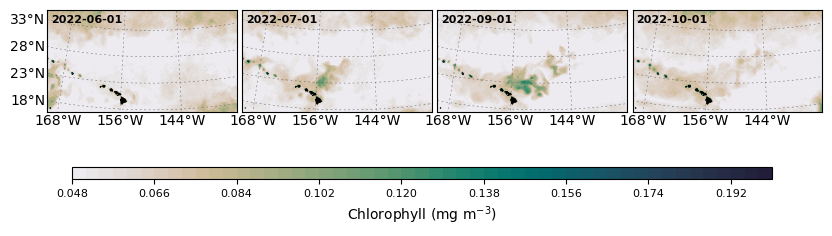

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(10, 3))

for i, ax in enumerate(axs.flat):
    idx = 96 + i

    m = Basemap(projection='lcc', resolution='h',
                llcrnrlat=16, urcrnrlat=35.5,
                llcrnrlon=-170, urcrnrlon=-130,
                lat_0=30, lon_0=-150,
                width=5.1E6, height=5E6,
                ax=ax)

    x, y = m(lon_grid, lat_grid)

    cp = m.contourf(x, y, ras_summer[idx, :, :],
                    levels=50, cmap=cmocean.cm.rain, extend='neither')

    ax.text(0.02, 0.95, date_str_summer[idx],
            transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            color='black')

    col = i
    par_labels = [1, 0, 0, 0] if col == 0 else [0, 0, 0, 0]
    m.drawparallels(np.arange(18, 40, 5), labels=par_labels,
                    color='dimgrey', fontsize=10, dashes=(3,5), linewidth=0.4)

    mer_labels = [0, 0, 0, 1]
    m.drawmeridians(np.arange(-168, -135, 12), labels=mer_labels,
                    color='dimgrey', fontsize=10, dashes=(3,5), linewidth=0.4)

    m.drawcoastlines(color='black', linewidth=0.5)
    m.fillcontinents(color='black')

plt.subplots_adjust(wspace=0.03)

cbar_ax = fig.add_axes([0.15, 0.1, 0.7, 0.04])
cbar = fig.colorbar(cp, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Chlorophyll (mg m$^{-3}$)', fontsize=10)
cbar.ax.tick_params(labelsize=8)
plt.savefig("chl_summer_page_5", dpi=600, bbox_inches='tight')

plt.show()